In [123]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import rgb_to_hsv
from PIL import Image


P4_ROOT = Path("../../images/p4")

image_paths = {
    "equalization_input": P4_ROOT / "equalization/input.png",
    "matching_source": P4_ROOT / "matching/source.png",
    "matching_reference": P4_ROOT / "matching/reference.png",
    "specification_source": P4_ROOT / "specification/source.png",
    "colour_source": P4_ROOT / "colour_source.png",
    "local_regions": P4_ROOT / "local_regions.png",
    "exposure_ev0": P4_ROOT / "exposure/ev0.png",
    "exposure_ev1": P4_ROOT / "exposure/ev1.png",
    "exposure_ev2": P4_ROOT / "exposure/ev2.png",
    "exposure_ev3": P4_ROOT / "exposure/ev3.png",
    "exposure_ev4": P4_ROOT / "exposure/ev4.png",
}

images = {
    name: np.array(Image.open(path))
    for name, path in image_paths.items()
}

print("Loaded image assets:")
for name, image in images.items():
    print(f"  {name}: shape={image.shape}, dtype={image.dtype}")

Loaded image assets:
  equalization_input: shape=(512, 512), dtype=uint8
  matching_source: shape=(512, 512), dtype=uint8
  matching_reference: shape=(303, 384), dtype=uint8
  specification_source: shape=(427, 640), dtype=uint8
  colour_source: shape=(512, 512, 3), dtype=uint8
  local_regions: shape=(1462, 2992, 3), dtype=uint8
  exposure_ev0: shape=(512, 512, 3), dtype=uint8
  exposure_ev1: shape=(512, 512, 3), dtype=uint8
  exposure_ev2: shape=(512, 512, 3), dtype=uint8
  exposure_ev3: shape=(512, 512, 3), dtype=uint8
  exposure_ev4: shape=(512, 512, 3), dtype=uint8


In [124]:
def hist(img, bins=256):
    return np.bincount(img.ravel(), minlength=bins).astype(np.float64)


In [125]:
def cdf(h):
    """Return the normalised inclusive cumulative histogram."""
    h = np.asarray(h, dtype=np.float64)

    if h.ndim != 1:
        raise ValueError("Histogram must be one-dimensional.")

    total = h.sum()

    if total <= 0:
        raise ValueError("Histogram must contain at least one sample.")

    return np.cumsum(h) / total

In [126]:
def equalise(img):
    """Apply T(v) = round(255 F(v)) using the inclusive normalised CDF."""
    img = np.asarray(img)

    if img.dtype != np.uint8:
        raise ValueError("Expected an 8-bit grayscale image.")

    mapping = np.floor(255.0 * cdf(hist(img)) + 0.5).astype(np.uint8)
    return mapping[img]

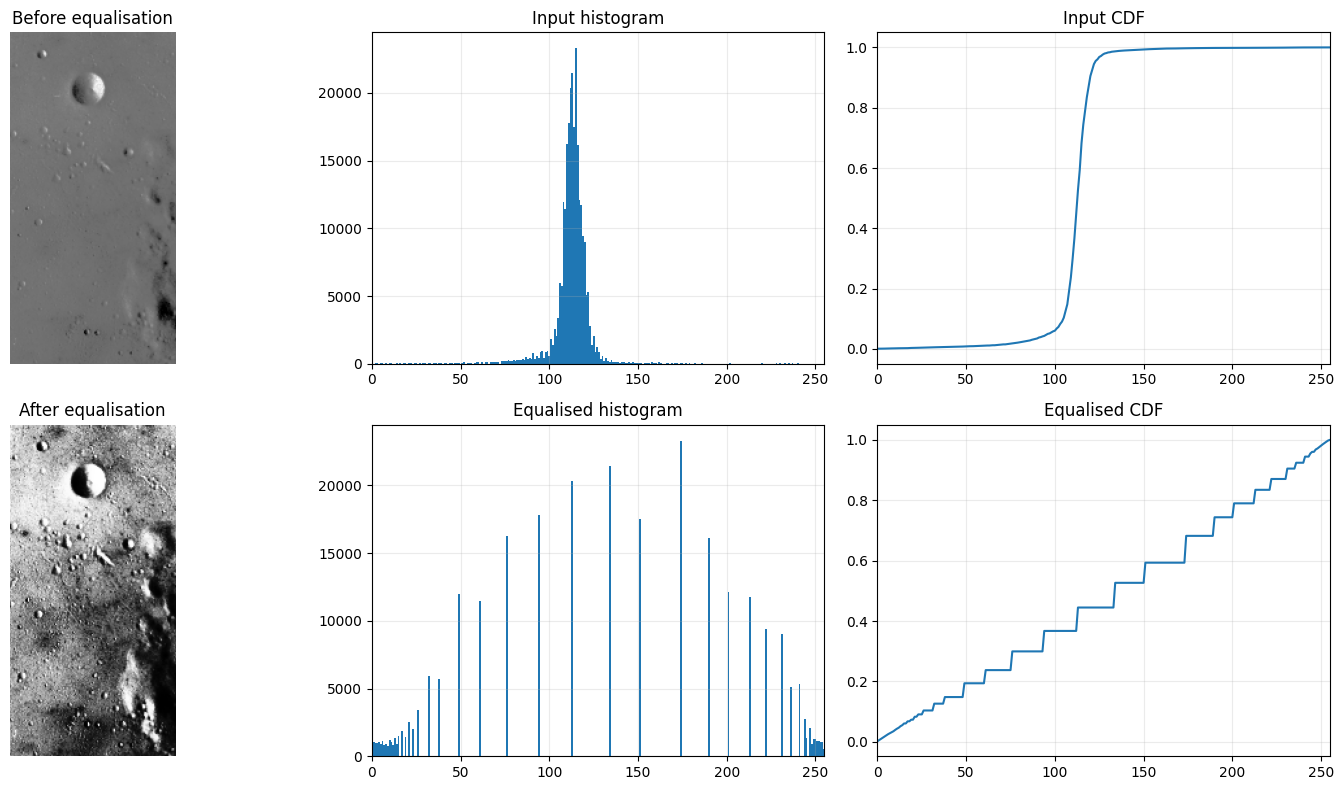

Input shape: (512, 512)
Input levels: 0 to 255
Equalised occupied levels: 49


In [127]:
input_image = images["equalization_input"]
equalized_image = equalise(input_image)

input_hist = hist(input_image)
equalized_hist = hist(equalized_image)
input_cdf = cdf(input_hist)
equalized_cdf = cdf(equalized_hist)
levels = np.arange(256)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(input_image, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Before equalisation")
axes[0, 1].bar(levels, input_hist, width=1.0)
axes[0, 1].set_title("Input histogram")
axes[0, 2].plot(levels, input_cdf)
axes[0, 2].set_title("Input CDF")

axes[1, 0].imshow(equalized_image, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("After equalisation")
axes[1, 1].bar(levels, equalized_hist, width=1.0)
axes[1, 1].set_title("Equalised histogram")
axes[1, 2].plot(levels, equalized_cdf)
axes[1, 2].set_title("Equalised CDF")

for axis in axes.flat:
    axis.set_xlim(0, 255)
    axis.grid(True, alpha=0.25)

axes[0, 0].axis("off")
axes[1, 0].axis("off")
plt.tight_layout()
plt.show()

print("Input shape:", input_image.shape)
print("Input levels:", np.where(input_hist > 0)[0].min(), "to", np.where(input_hist > 0)[0].max())
print("Equalised occupied levels:", int(np.count_nonzero(equalized_hist)))

In [128]:
# Required checks for 4.1(a)-(c).
occupied_output_bins = np.count_nonzero(equalized_hist)
print("Occupied equalised histogram bins:", occupied_output_bins)

# A flat 256-bin histogram must occupy every output level.
assert occupied_output_bins < 256

# Exact idempotence for this discrete CDF rule.
second_equalization = equalise(equalized_image)
print(
    "Equalisation is idempotent on the supplied image:",
    np.array_equal(equalized_image, second_equalization),
)
assert np.array_equal(equalized_image, second_equalization)

# Construct an image containing each level 1,...,255 once.
identity_example = np.arange(1, 256, dtype=np.uint8).reshape(15, 17)
identity_result = equalise(identity_example)

print(
    "Identity example unchanged:",
    np.array_equal(identity_example, identity_result),
)
assert np.array_equal(identity_example, identity_result)

Occupied equalised histogram bins: 49
Equalisation is idempotent on the supplied image: True
Identity example unchanged: True


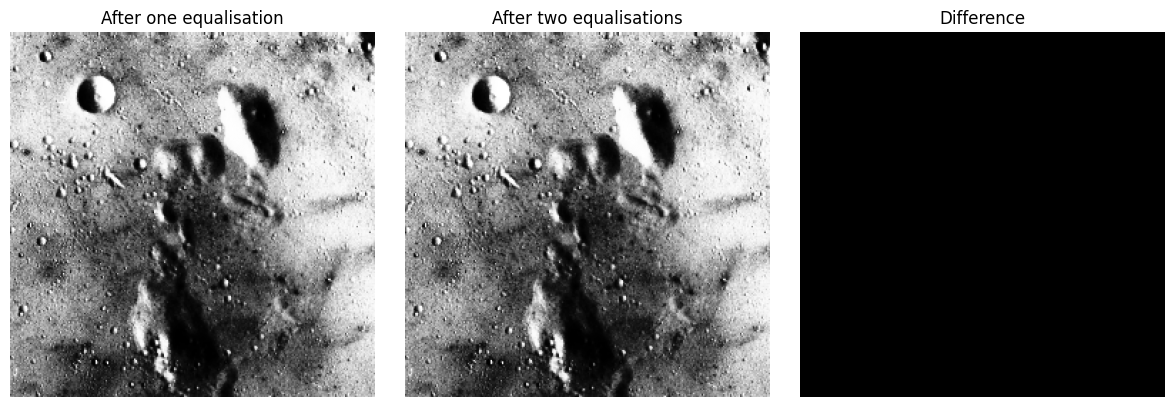

In [129]:
# 4.1(b) Separate visual evidence: equalisation is idempotent.
idempotence_difference = np.abs(
    equalized_image.astype(np.int16) -
    second_equalization.astype(np.int16)
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for axis, image, title in zip(
    axes,
    (equalized_image, second_equalization, idempotence_difference),
    ("After one equalisation", "After two equalisations", "Difference"),
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()

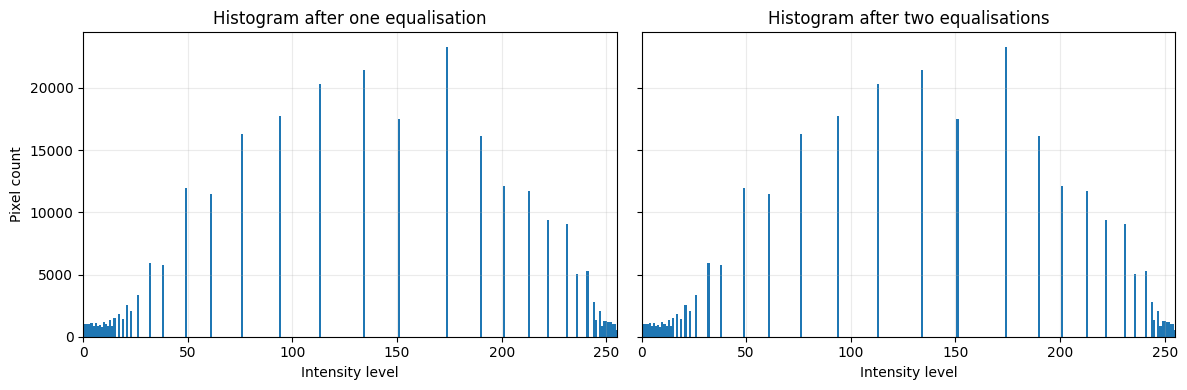

Occupied bins after one equalisation: 49
Occupied bins after two equalisations: 49


In [130]:
# 4.1(b) Histogram comparison: one versus two equalisations.
double_equalized_hist = hist(second_equalization)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for axis, histogram, title in zip(
    axes,
    (equalized_hist, double_equalized_hist),
    (
        "Histogram after one equalisation",
        "Histogram after two equalisations",
    ),
):
    axis.bar(levels, histogram, width=1.0)
    axis.set_title(title)
    axis.set_xlabel("Intensity level")
    axis.set_xlim(0, 255)
    axis.grid(True, alpha=0.25)

axes[0].set_ylabel("Pixel count")
plt.tight_layout()
plt.show()

print("Occupied bins after one equalisation:", np.count_nonzero(equalized_hist))
print("Occupied bins after two equalisations:", np.count_nonzero(double_equalized_hist))

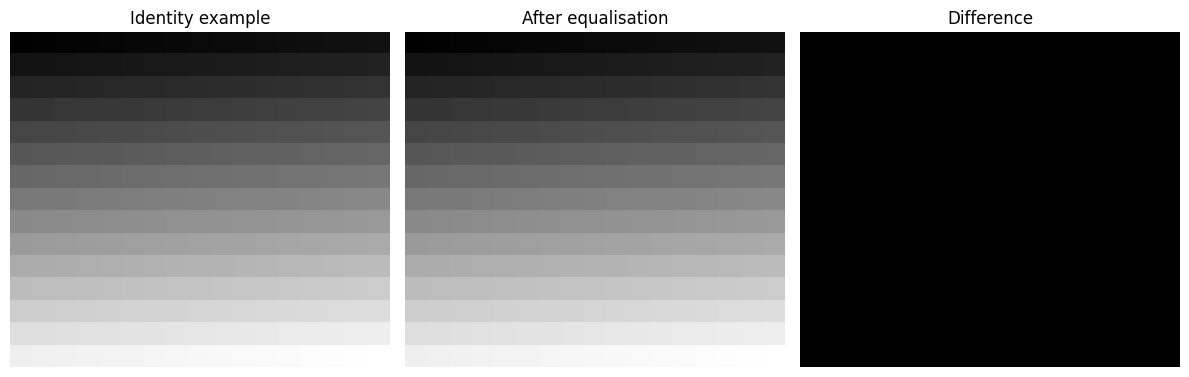

In [131]:
# 4.1(c) Separate visual evidence: an identity example.
identity_difference = np.abs(
    identity_example.astype(np.int16) -
    identity_result.astype(np.int16)
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for axis, image, title in zip(
    axes,
    (identity_example, identity_result, identity_difference),
    ("Identity example", "After equalisation", "Difference"),
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()

In [132]:
def specify(img, target_hist):
    """Match a grayscale image to an arbitrary prescribed target histogram."""
    img = np.asarray(img)
    target_hist = np.asarray(target_hist, dtype=np.float64)

    if img.dtype != np.uint8 or img.ndim != 2:
        raise ValueError("Expected a uint8 grayscale image.")
    if target_hist.shape != (256,):
        raise ValueError("Target histogram must have 256 bins.")
    if np.any(target_hist < 0) or target_hist.sum() <= 0:
        raise ValueError("Target histogram must be non-negative and non-empty.")

    source_cdf = cdf(hist(img))
    target_cdf = cdf(target_hist)
    mapping = np.searchsorted(target_cdf, source_cdf, side="left")
    mapping = np.clip(mapping, 0, 255).astype(np.uint8)

    return mapping[img]

In [133]:
def wasserstein1(h1, h2):
    """Return the 1D Wasserstein distance for unit-spaced intensity bins."""
    h1 = np.asarray(h1, dtype=np.float64)
    h2 = np.asarray(h2, dtype=np.float64)

    if h1.shape != h2.shape or h1.ndim != 1:
        raise ValueError("Histograms must be one-dimensional and equally sized.")
    if np.any(h1 < 0) or np.any(h2 < 0):
        raise ValueError("Histograms must be non-negative.")
    if h1.sum() <= 0 or h2.sum() <= 0:
        raise ValueError("Histograms must contain at least one sample.")

    return float(np.abs(cdf(h1) - cdf(h2)).sum())

In [134]:
def apply_on_luma(rgb, fn):
    """Equalise BT.601 luma and reconstruct RGB while preserving chroma."""
    rgb = np.asarray(rgb)

    if rgb.dtype != np.uint8 or rgb.ndim != 3 or rgb.shape[2] != 3:
        raise ValueError("Expected a uint8 RGB image.")

    rgb_float = rgb.astype(np.float64) / 255.0
    luma = (
        0.299 * rgb_float[..., 0]
        + 0.587 * rgb_float[..., 1]
        + 0.114 * rgb_float[..., 2]
    )
    luma_uint8 = np.rint(255.0 * luma).clip(0, 255).astype(np.uint8)
    new_luma = fn(luma_uint8).astype(np.float64) / 255.0

    scale = np.divide(
        new_luma,
        luma,
        out=np.zeros_like(new_luma),
        where=luma > 0,
    )
    result = np.clip(rgb_float * scale[..., None], 0.0, 1.0)
    zero_luma = luma == 0
    result[zero_luma] = 0.0

    return np.rint(255.0 * result).astype(np.uint8)

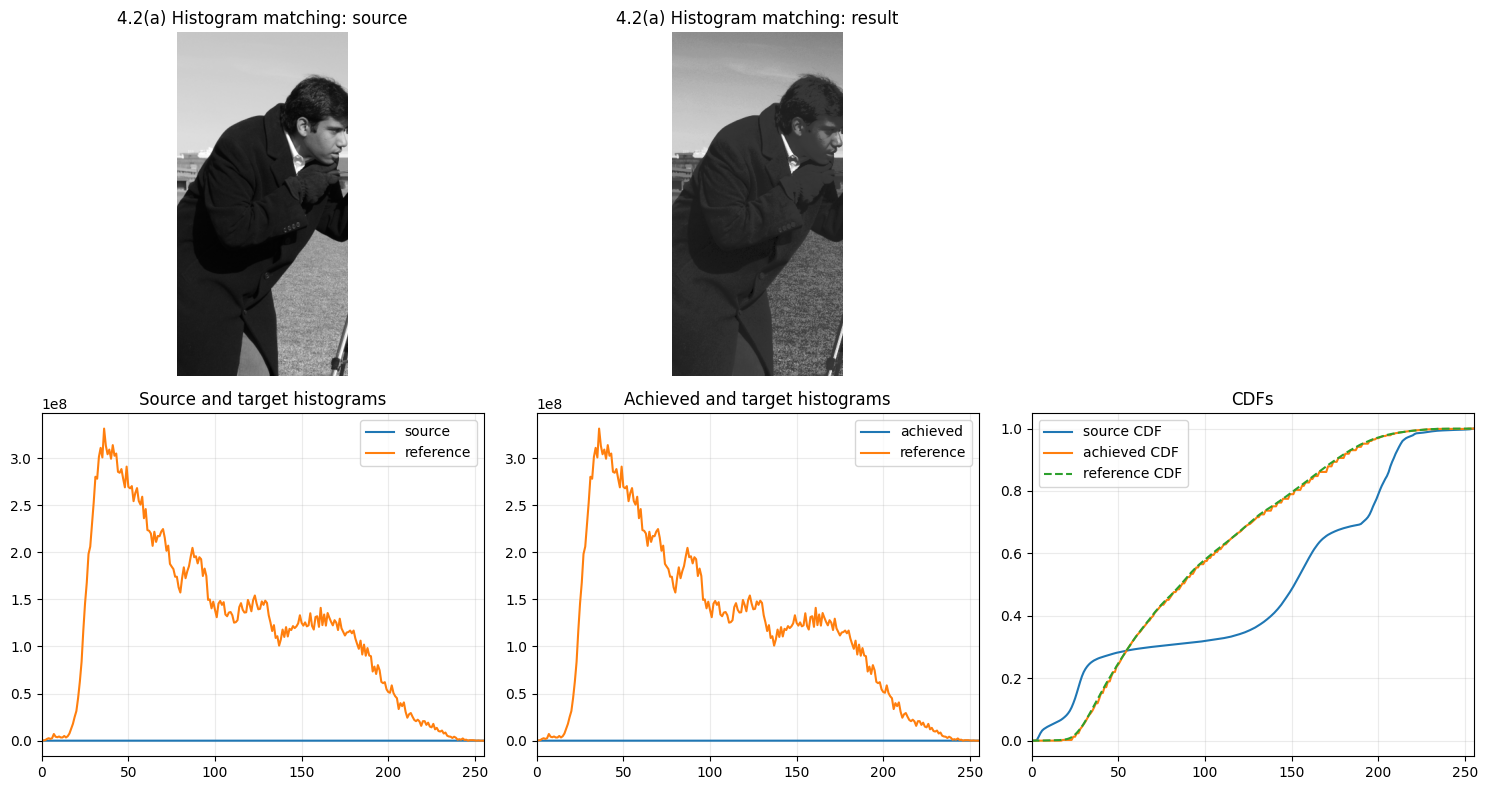

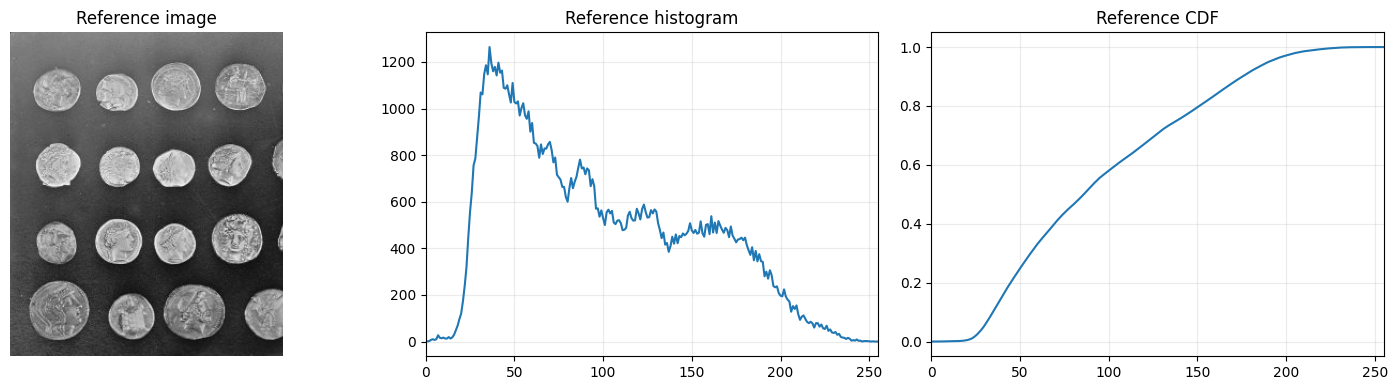

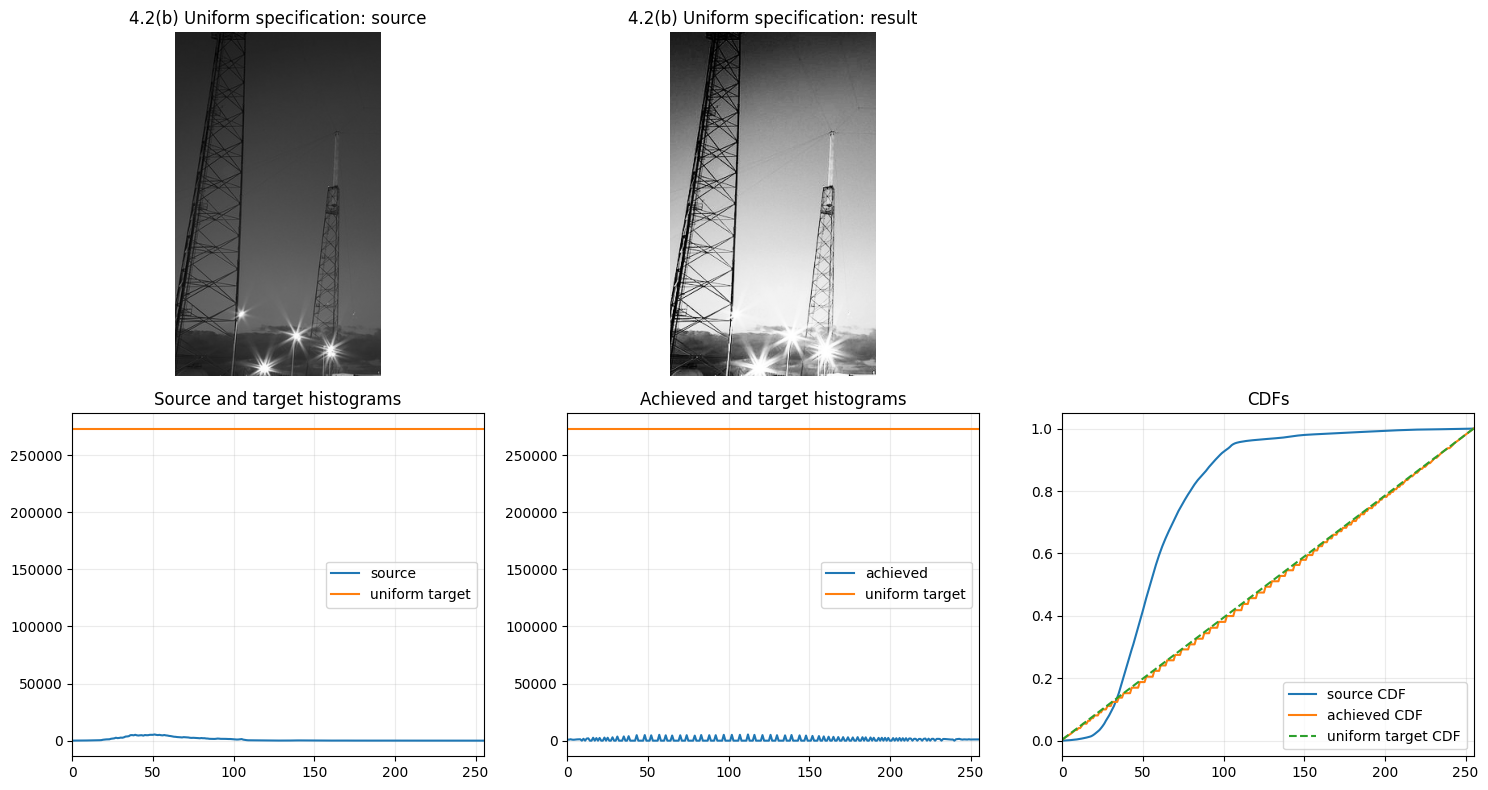

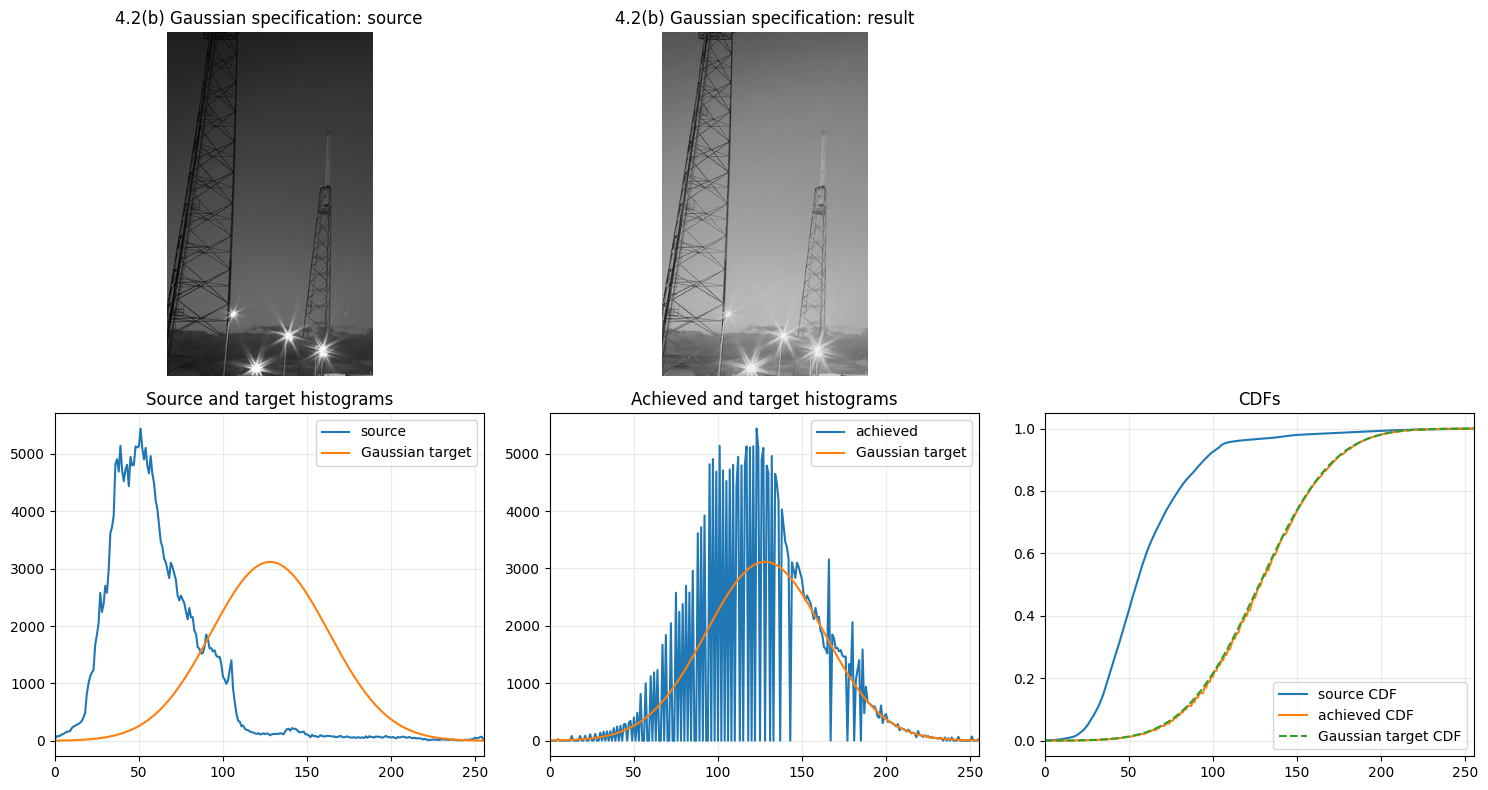

Wasserstein-1 distances (before, after):
  matching/reference: 40.774623, 0.860480
  uniform: 69.146399, 1.604801
  Gaussian(mu=128,sigma=35): 67.085189, 0.767012


In [135]:
# 4.2(a)-(b): matching and histogram specification.
def gaussian_target(mu=128.0, sigma=35.0):
    target = np.exp(-0.5 * ((levels - mu) / sigma) ** 2)
    return target / target.sum()


def plot_gray_result(source, result, target_hist, title, target_name):
    source_hist = hist(source)
    result_hist = hist(result)
    source_cdf = cdf(source_hist)
    result_cdf = cdf(result_hist)
    target_cdf = cdf(target_hist)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0, 0].imshow(source, cmap="gray", vmin=0, vmax=255)
    axes[0, 0].set_title(f"{title}: source")
    axes[0, 1].imshow(result, cmap="gray", vmin=0, vmax=255)
    axes[0, 1].set_title(f"{title}: result")
    axes[0, 2].axis("off")

    axes[1, 0].plot(levels, source_hist, label="source")
    axes[1, 0].plot(levels, target_hist * source.size, label=target_name)
    axes[1, 0].set_title("Source and target histograms")
    axes[1, 0].legend()

    axes[1, 1].plot(levels, result_hist, label="achieved")
    axes[1, 1].plot(levels, target_hist * result.size, label=target_name)
    axes[1, 1].set_title("Achieved and target histograms")
    axes[1, 1].legend()

    axes[1, 2].plot(levels, source_cdf, label="source CDF")
    axes[1, 2].plot(levels, result_cdf, label="achieved CDF")
    axes[1, 2].plot(levels, target_cdf, "--", label=f"{target_name} CDF")
    axes[1, 2].set_title("CDFs")
    axes[1, 2].legend()

    for axis in axes.flat:
        axis.set_xlim(0, 255)
        axis.grid(True, alpha=0.25)
    axes[0, 0].axis("off")
    axes[0, 1].axis("off")
    plt.tight_layout()
    plt.show()

    return source_hist, result_hist


matching_source = images["matching_source"]
matching_reference = images["matching_reference"]
matching_target_hist = hist(matching_reference)
matching_result = specify(matching_source, matching_target_hist)

uniform_target_hist = np.ones(256, dtype=np.float64)
uniform_result = specify(images["specification_source"], uniform_target_hist)

gaussian_target_hist = gaussian_target(mu=128.0, sigma=35.0)
gaussian_result = specify(images["specification_source"], gaussian_target_hist)

matching_source_hist, matching_result_hist = plot_gray_result(
    matching_source,
    matching_result,
    matching_target_hist,
    "4.2(a) Histogram matching",
    "reference",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(matching_reference, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Reference image")
axes[1].plot(levels, matching_target_hist)
axes[1].set_title("Reference histogram")
axes[2].plot(levels, cdf(matching_target_hist))
axes[2].set_title("Reference CDF")
for axis in axes:
    axis.set_xlim(0, 255)
    axis.grid(True, alpha=0.25)
axes[0].axis("off")
plt.tight_layout()
plt.show()

spec_source = images["specification_source"]
uniform_source_hist, uniform_result_hist = plot_gray_result(
    spec_source,
    uniform_result,
    uniform_target_hist,
    "4.2(b) Uniform specification",
    "uniform target",
)
_, gaussian_result_hist = plot_gray_result(
    spec_source,
    gaussian_result,
    gaussian_target_hist,
    "4.2(b) Gaussian specification",
    "Gaussian target",
)

scores_42 = {
    "matching/reference": (
        wasserstein1(matching_source_hist, matching_target_hist),
        wasserstein1(matching_result_hist, matching_target_hist),
    ),
    "uniform": (
        wasserstein1(hist(spec_source), uniform_target_hist),
        wasserstein1(uniform_result_hist, uniform_target_hist),
    ),
    "Gaussian(mu=128,sigma=35)": (
        wasserstein1(hist(spec_source), gaussian_target_hist),
        wasserstein1(gaussian_result_hist, gaussian_target_hist),
    ),
}

print("Wasserstein-1 distances (before, after):")
for name, (before, after) in scores_42.items():
    print(f"  {name}: {before:.6f}, {after:.6f}")

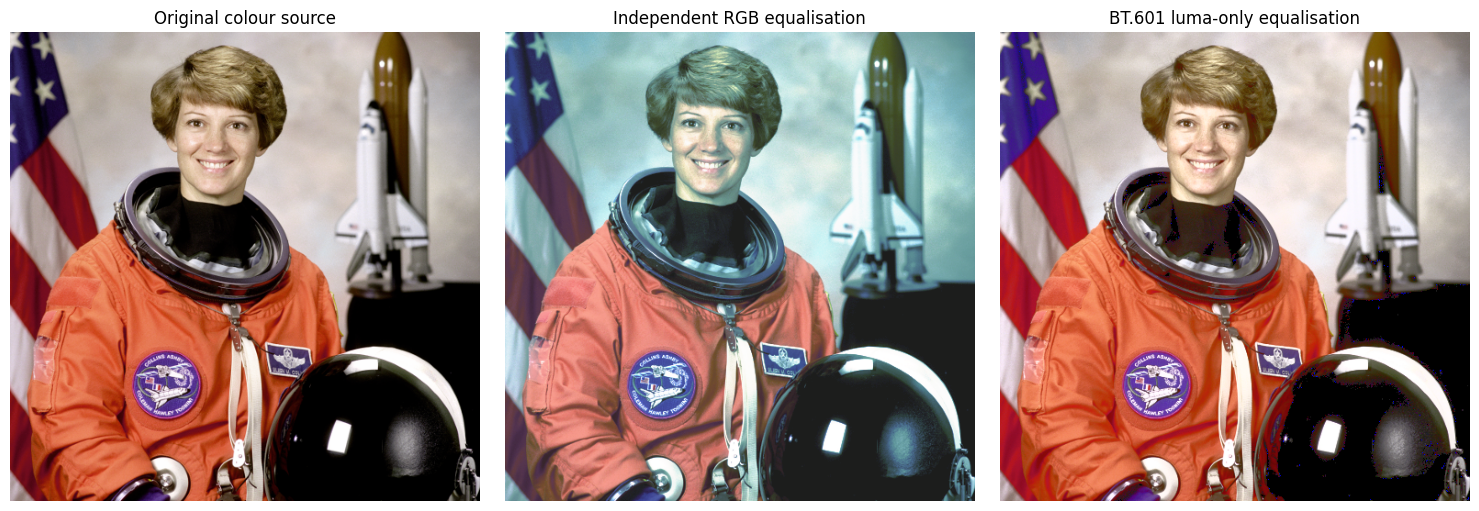

Colour space: RGB with BT.601 luma Y = 0.299R + 0.587G + 0.114B
Hue distance: d(h1,h2) = 360 * |((h2-h1+0.5) mod 1) - 0.5|
Saturation threshold: S >= 0.05 in both original and result
RGB-channel mean hue shift: 81.707249 degrees (196675 pixels)
Luma-only mean hue shift: 0.574743 degrees (198799 pixels)


In [136]:
# 4.2(c): colour equalisation comparison.
def equalise_rgb_channels(rgb):
    return np.stack(
        [equalise(rgb[..., channel]) for channel in range(3)],
        axis=-1,
    )


def circular_hue_distance(hue_a, hue_b):
    """Return shortest hue distance in degrees for hues represented in [0, 1]."""
    return np.abs((hue_b - hue_a + 0.5) % 1.0 - 0.5) * 360.0


def mean_hue_shift(original, result, saturation_threshold=0.05):
    original_hsv = rgb_to_hsv(original.astype(np.float64) / 255.0)
    result_hsv = rgb_to_hsv(result.astype(np.float64) / 255.0)

    valid = (
        (original_hsv[..., 1] >= saturation_threshold)
        & (result_hsv[..., 1] >= saturation_threshold)
    )
    distances = circular_hue_distance(
        original_hsv[..., 0],
        result_hsv[..., 0],
    )

    return float(distances[valid].mean()), int(valid.sum()), valid


colour_source = images["colour_source"]
colour_rgb_result = equalise_rgb_channels(colour_source)
colour_luma_result = apply_on_luma(colour_source, equalise)

rgb_hue_shift, rgb_hue_count, _ = mean_hue_shift(
    colour_source,
    colour_rgb_result,
    saturation_threshold=0.05,
)
luma_hue_shift, luma_hue_count, _ = mean_hue_shift(
    colour_source,
    colour_luma_result,
    saturation_threshold=0.05,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, image, title in zip(
    axes,
    (colour_source, colour_rgb_result, colour_luma_result),
    (
        "Original colour source",
        "Independent RGB equalisation",
        "BT.601 luma-only equalisation",
    ),
):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Colour space: RGB with BT.601 luma Y = 0.299R + 0.587G + 0.114B")
print("Hue distance: d(h1,h2) = 360 * |((h2-h1+0.5) mod 1) - 0.5|")
print("Saturation threshold: S >= 0.05 in both original and result")
print(f"RGB-channel mean hue shift: {rgb_hue_shift:.6f} degrees ({rgb_hue_count} pixels)")
print(f"Luma-only mean hue shift: {luma_hue_shift:.6f} degrees ({luma_hue_count} pixels)")

### 4.2 Interpretation

Uniform specification uses an explicitly uniform 256-bin target distribution. It is therefore the same target distribution as the CDF equalisation objective, but inverse-CDF specification makes the target explicit and uses the prescribed target histogram. In finite 8-bit images, both can still have quantisation and histogram collisions.

Independent RGB equalisation is inappropriate because equalisation assumes a scalar ordered intensity coordinate. Applying three unrelated monotone mappings changes the relative channel ratios, so hue and saturation can change. Luma-only equalisation applies one mapping to a brightness coordinate and preserves the chromatic direction much better.

In [137]:
def to_luma(rgb):
    """Convert uint8 RGB to the required BT.601 uint8 luminance."""
    rgb = np.asarray(rgb)

    if rgb.dtype != np.uint8 or rgb.ndim != 3 or rgb.shape[2] != 3:
        raise ValueError("Expected a uint8 RGB image.")

    return np.rint(
        0.299 * rgb[..., 0]
        + 0.587 * rgb[..., 1]
        + 0.114 * rgb[..., 2]
    ).clip(0, 255).astype(np.uint8)


def tile_edges(shape, tiles):
    if not isinstance(tiles, int) or tiles < 1:
        raise ValueError("tiles must be a positive integer.")

    row_edges = np.linspace(0, shape[0], tiles + 1, dtype=int)
    col_edges = np.linspace(0, shape[1], tiles + 1, dtype=int)
    return row_edges, col_edges


def tile_lut(tile, clip=np.inf):
    counts = hist(tile)

    if np.isfinite(clip):
        limit = clip * tile.size / 256.0
        clipped = np.minimum(counts, limit)
        excess = int(np.rint(np.maximum(counts - limit, 0).sum()))
        counts = clipped + excess // 256
        counts[:excess % 256] += 1

    return np.floor(255.0 * cdf(counts) + 0.5).astype(np.uint8)


def ahe(img, tiles=8):
    """Plain tiled AHE: independent tile LUTs with no interpolation."""
    img = np.asarray(img)

    if img.dtype != np.uint8 or img.ndim != 2:
        raise ValueError("Expected a uint8 grayscale image.")

    row_edges, col_edges = tile_edges(img.shape, tiles)
    result = np.empty_like(img)

    for row in range(tiles):
        for col in range(tiles):
            r0, r1 = row_edges[row], row_edges[row + 1]
            c0, c1 = col_edges[col], col_edges[col + 1]
            lut = tile_lut(img[r0:r1, c0:c1])
            result[r0:r1, c0:c1] = lut[img[r0:r1, c0:c1]]

    return result

In [138]:
def clahe(img, tiles=8, clip=3.0, bins=256):
    """Tiled CLAHE with clipping, redistribution, and bilinear interpolation."""
    img = np.asarray(img)

    if img.dtype != np.uint8 or img.ndim != 2:
        raise ValueError("Expected a uint8 grayscale image.")
    if bins != 256:
        raise ValueError("This implementation expects 256 intensity bins.")
    if clip <= 0 and not np.isinf(clip):
        raise ValueError("clip must be positive or infinity.")

    row_edges, col_edges = tile_edges(img.shape, tiles)
    row_centres = (row_edges[:-1] + row_edges[1:] - 1) / 2.0
    col_centres = (col_edges[:-1] + col_edges[1:] - 1) / 2.0

    luts = np.empty((tiles, tiles, 256), dtype=np.uint8)
    for tile_row in range(tiles):
        for tile_col in range(tiles):
            r0, r1 = row_edges[tile_row], row_edges[tile_row + 1]
            c0, c1 = col_edges[tile_col], col_edges[tile_col + 1]
            luts[tile_row, tile_col] = tile_lut(
                img[r0:r1, c0:c1],
                clip=clip,
            )

    rows = np.arange(img.shape[0])
    cols = np.arange(img.shape[1])
    row_hi = np.clip(
        np.searchsorted(row_centres, rows, side="right"),
        1,
        tiles - 1,
    )
    col_hi = np.clip(
        np.searchsorted(col_centres, cols, side="right"),
        1,
        tiles - 1,
    )
    row_lo = row_hi - 1
    col_lo = col_hi - 1

    row_weight = np.divide(
        rows - row_centres[row_lo],
        row_centres[row_hi] - row_centres[row_lo],
        out=np.zeros_like(rows, dtype=np.float64),
        where=row_centres[row_hi] != row_centres[row_lo],
    )
    col_weight = np.divide(
        cols - col_centres[col_lo],
        col_centres[col_hi] - col_centres[col_lo],
        out=np.zeros_like(cols, dtype=np.float64),
        where=col_centres[col_hi] != col_centres[col_lo],
    )

    row_weight[: int(row_centres[0]) + 1] = 0.0
    row_weight[int(row_centres[-1]) :] = 1.0
    col_weight[: int(col_centres[0]) + 1] = 0.0
    col_weight[int(col_centres[-1]) :] = 1.0

    output = np.empty(img.shape, dtype=np.float64)

    for pixel_row in range(img.shape[0]):
        intensity = img[pixel_row]
        top_left = luts[row_lo[pixel_row], col_lo, intensity]
        top_right = luts[row_lo[pixel_row], col_hi, intensity]
        bottom_left = luts[row_hi[pixel_row], col_lo, intensity]
        bottom_right = luts[row_hi[pixel_row], col_hi, intensity]

        horizontal_top = (
            (1.0 - col_weight) * top_left
            + col_weight * top_right
        )
        horizontal_bottom = (
            (1.0 - col_weight) * bottom_left
            + col_weight * bottom_right
        )
        output[pixel_row] = (
            (1.0 - row_weight[pixel_row]) * horizontal_top
            + row_weight[pixel_row] * horizontal_bottom
        )

    return np.rint(output).clip(0, 255).astype(np.uint8)

Local luminance: shape=(1462, 2992), dtype=uint8, range=0-255


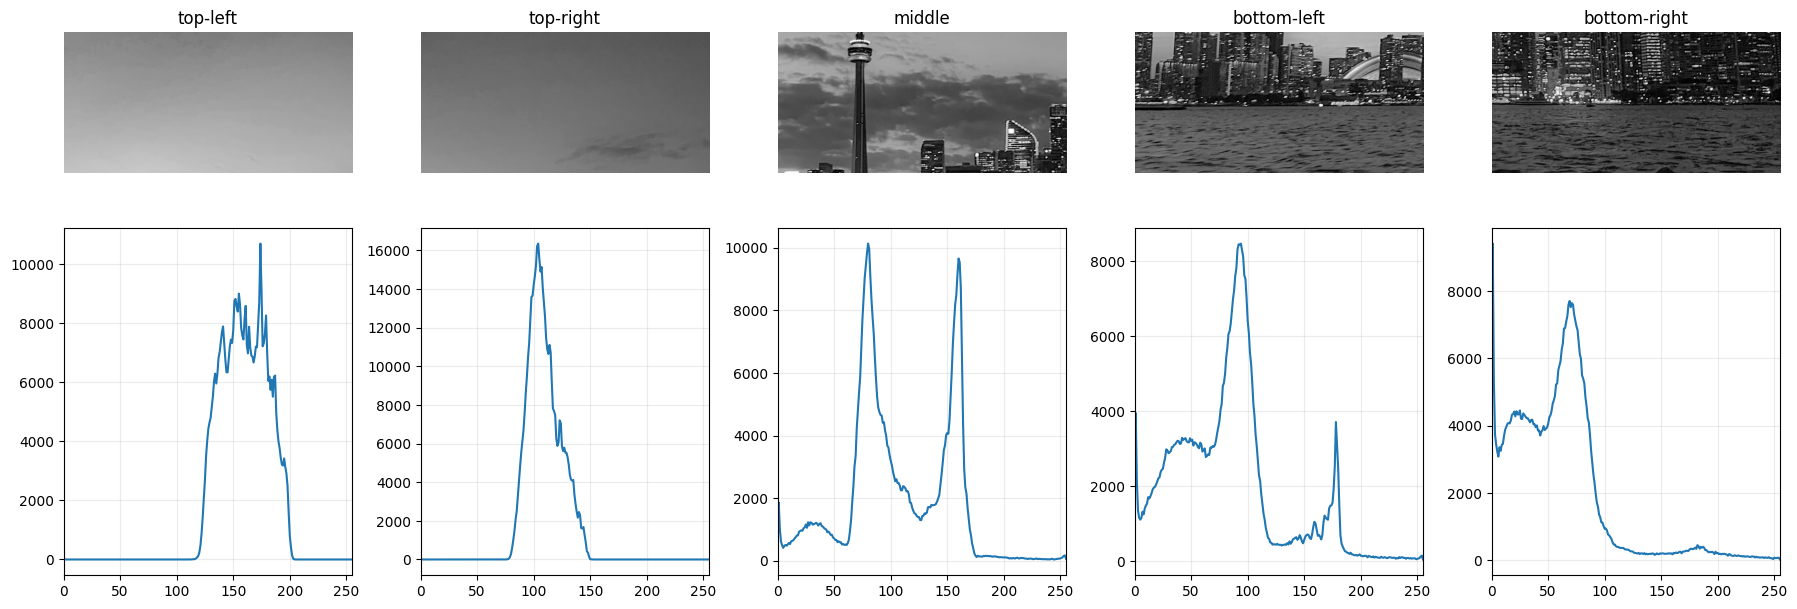

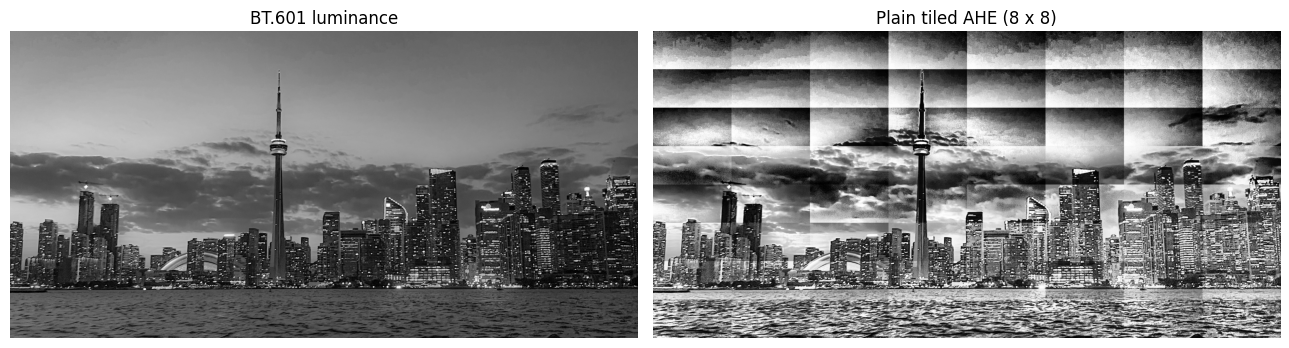

Plain AHE failure 1: independent tile LUTs create visible seams at tile boundaries.
Plain AHE failure 2: small or nearly uniform tiles amplify noise and create speckle/over-enhancement.


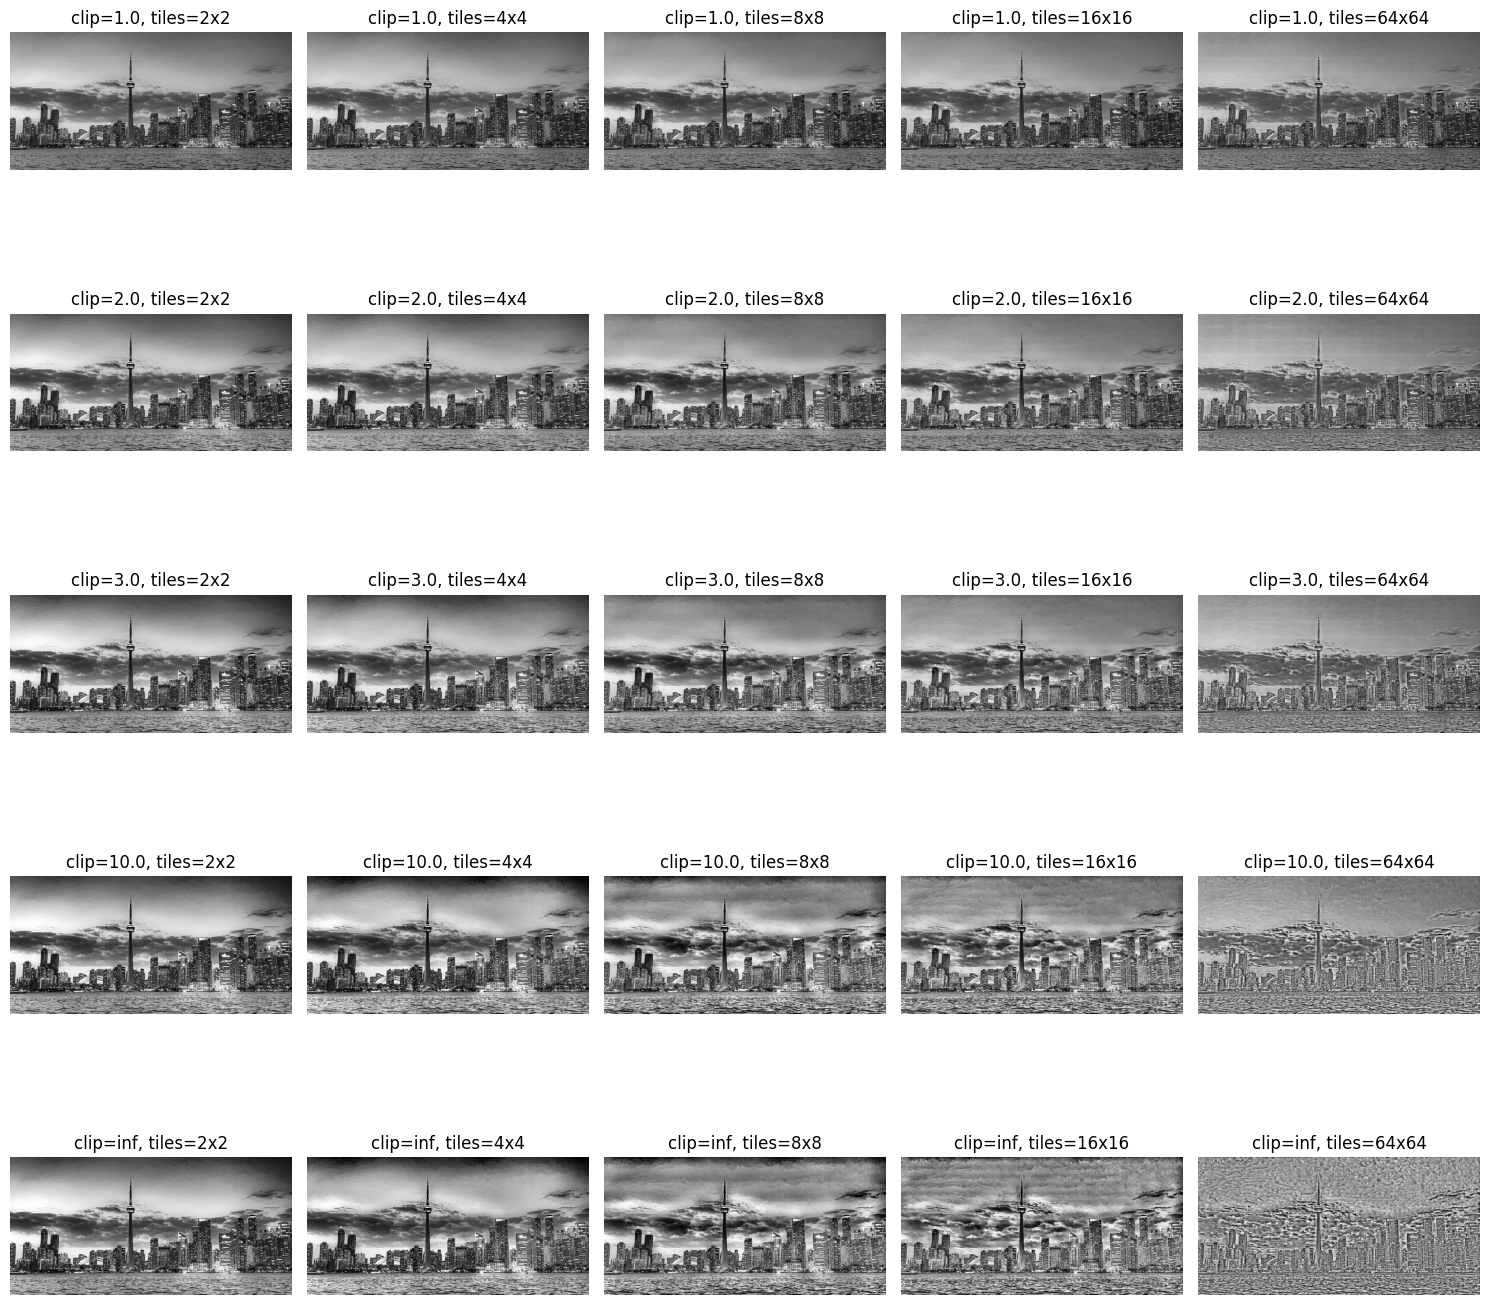

CLAHE degenerate ends: clip=1 is strongly clipped and approaches local mean-preserving contrast compression.
CLAHE degenerate ends: clip=infinity becomes AHE, so noise amplification and seams return.
CLAHE degenerate ends: 2x2 is very global and misses local variation; 64x64 uses tiny tiles and becomes noisy/block-sensitive.


In [139]:
def local_specification(img, target_hist, tiles=8):
    """Specify each tile to one prescribed target histogram without interpolation."""
    img = np.asarray(img)
    target_hist = np.asarray(target_hist, dtype=np.float64)
    row_edges, col_edges = tile_edges(img.shape, tiles)
    result = np.empty_like(img)

    for row in range(tiles):
        for col in range(tiles):
            r0, r1 = row_edges[row], row_edges[row + 1]
            c0, c1 = col_edges[col], col_edges[col + 1]
            result[r0:r1, c0:c1] = specify(
                img[r0:r1, c0:c1],
                target_hist,
            )

    return result


local_rgb = images["local_regions"]
local_luma = to_luma(local_rgb)

print(
    "Local luminance:",
    f"shape={local_luma.shape}, dtype={local_luma.dtype}, "
    f"range={local_luma.min()}-{local_luma.max()}"
)

# 4.3(a): histograms from five distinct local patches.
patch_boxes = {
    "top-left": (0, local_luma.shape[0] // 3, 0, local_luma.shape[1] // 3),
    "top-right": (0, local_luma.shape[0] // 3, 2 * local_luma.shape[1] // 3, local_luma.shape[1]),
    "middle": (local_luma.shape[0] // 3, 2 * local_luma.shape[0] // 3, local_luma.shape[1] // 3, 2 * local_luma.shape[1] // 3),
    "bottom-left": (2 * local_luma.shape[0] // 3, local_luma.shape[0], 0, local_luma.shape[1] // 3),
    "bottom-right": (2 * local_luma.shape[0] // 3, local_luma.shape[0], 2 * local_luma.shape[1] // 3, local_luma.shape[1]),
}

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for column, (name, (r0, r1, c0, c1)) in enumerate(patch_boxes.items()):
    patch = local_luma[r0:r1, c0:c1]
    axes[0, column].imshow(patch, cmap="gray", vmin=0, vmax=255)
    axes[0, column].set_title(name)
    axes[0, column].axis("off")
    axes[1, column].plot(levels, hist(patch))
    axes[1, column].set_xlim(0, 255)
    axes[1, column].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# 4.3(b): plain tiled AHE and its boundary artifacts.
ahe_result = ahe(local_luma, tiles=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(local_luma, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("BT.601 luminance")
axes[1].imshow(ahe_result, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Plain tiled AHE (8 x 8)")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Plain AHE failure 1: independent tile LUTs create visible seams at tile boundaries.")
print("Plain AHE failure 2: small or nearly uniform tiles amplify noise and create speckle/over-enhancement.")

# 4.3(c)-(d): CLAHE and the requested clip/tile ablation grid.
clahe_result = clahe(local_luma, tiles=8, clip=3.0)

clip_values = [1.0, 2.0, 3.0, 10.0, np.inf]
tile_values = [2, 4, 8, 16, 64]

fig, axes = plt.subplots(
    len(clip_values),
    len(tile_values),
    figsize=(15, 15),
)
for row, clip_value in enumerate(clip_values):
    for column, tile_count in enumerate(tile_values):
        result = clahe(local_luma, tiles=tile_count, clip=clip_value)
        axes[row, column].imshow(result, cmap="gray", vmin=0, vmax=255)
        clip_name = "inf" if np.isinf(clip_value) else str(clip_value)
        axes[row, column].set_title(f"clip={clip_name}, tiles={tile_count}x{tile_count}")
        axes[row, column].axis("off")

plt.tight_layout()
plt.show()

print("CLAHE degenerate ends: clip=1 is strongly clipped and approaches local mean-preserving contrast compression.")
print("CLAHE degenerate ends: clip=infinity becomes AHE, so noise amplification and seams return.")
print("CLAHE degenerate ends: 2x2 is very global and misses local variation; 64x64 uses tiny tiles and becomes noisy/block-sensitive.")

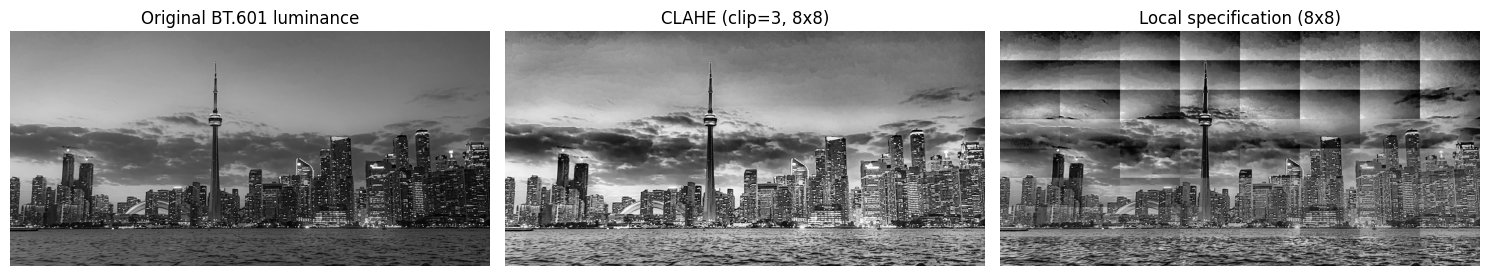

Local specification target: global luminance histogram of local_regions.png
Mean tile W1 to supplied target:
  CLAHE: 33.105359
  Local specification: 2.349362
Extra information required: a prescribed target histogram for each local region.


In [140]:
# 4.3(e): local histogram specification versus CLAHE.
# Extra information supplied: the desired target histogram, here the global
# luminance histogram of the same image.
local_target_hist = hist(local_luma)
local_spec_result = local_specification(
    local_luma,
    local_target_hist,
    tiles=8,
)

row_edges, col_edges = tile_edges(local_luma.shape, 8)
clahe_tile_distances = []
spec_tile_distances = []

for row in range(8):
    for col in range(8):
        r0, r1 = row_edges[row], row_edges[row + 1]
        c0, c1 = col_edges[col], col_edges[col + 1]
        target = local_target_hist
        clahe_tile_distances.append(
            wasserstein1(hist(clahe_result[r0:r1, c0:c1]), target)
        )
        spec_tile_distances.append(
            wasserstein1(hist(local_spec_result[r0:r1, c0:c1]), target)
        )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, image, title in zip(
    axes,
    (local_luma, clahe_result, local_spec_result),
    (
        "Original BT.601 luminance",
        "CLAHE (clip=3, 8x8)",
        "Local specification (8x8)",
    ),
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Local specification target: global luminance histogram of local_regions.png")
print("Mean tile W1 to supplied target:")
print(f"  CLAHE: {np.mean(clahe_tile_distances):.6f}")
print(f"  Local specification: {np.mean(spec_tile_distances):.6f}")
print("Extra information required: a prescribed target histogram for each local region.")

In [141]:
def apply_on_luma(rgb, fn):
    """Equalise BT.601 luma and reconstruct RGB while preserving chroma."""
    rgb = np.asarray(rgb)

    if rgb.dtype != np.uint8 or rgb.ndim != 3 or rgb.shape[2] != 3:
        raise ValueError("Expected a uint8 RGB image.")

    rgb_float = rgb.astype(np.float64) / 255.0
    luma = (
        0.299 * rgb_float[..., 0]
        + 0.587 * rgb_float[..., 1]
        + 0.114 * rgb_float[..., 2]
    )
    luma_uint8 = np.rint(255.0 * luma).clip(0, 255).astype(np.uint8)
    new_luma = fn(luma_uint8).astype(np.float64) / 255.0

    scale = np.divide(
        new_luma,
        luma,
        out=np.zeros_like(new_luma),
        where=luma > 0,
    )
    result = np.clip(rgb_float * scale[..., None], 0.0, 1.0)
    zero_luma = luma == 0
    result[zero_luma] = 0.0

    return np.rint(255.0 * result).astype(np.uint8)

In [142]:
def auto_correct(rgb):
    """Correct exposure from the image median with a fixed smooth tone curve."""
    rgb = np.asarray(rgb)

    if rgb.dtype != np.uint8 or rgb.ndim != 3 or rgb.shape[2] != 3:
        raise ValueError("Expected a uint8 RGB image.")

    rgb_float = rgb.astype(np.float64) / 255.0
    luma = (
        0.299 * rgb_float[..., 0]
        + 0.587 * rgb_float[..., 1]
        + 0.114 * rgb_float[..., 2]
    )

    positive_luma = luma[luma > 0]
    if positive_luma.size == 0:
        return rgb.copy()

    median_luma = np.median(positive_luma)
    relative_luma = luma / max(median_luma, np.finfo(float).eps)
    corrected_luma = relative_luma / (1.0 + relative_luma)
    corrected_luma[luma == 0] = 0.0

    scale = np.divide(
        corrected_luma,
        luma,
        out=np.zeros_like(luma),
        where=luma > 0,
    )
    corrected = np.clip(rgb_float * scale[..., None], 0.0, 1.0)
    corrected[luma == 0] = 0.0

    return np.rint(255.0 * corrected).astype(np.uint8)

4.4 pairwise normalized-luminance W1 distances:
EV0-EV1: before=28.906467, after=0.604511
EV0-EV2: before=86.632023, after=0.800560
EV0-EV3: before=143.018230, after=7.892471
EV0-EV4: before=165.310799, after=16.205757
EV1-EV2: before=57.725555, after=0.221569
EV1-EV3: before=114.111763, after=7.621479
EV1-EV4: before=136.404331, after=15.972485
EV2-EV3: before=56.386208, after=7.430840
EV2-EV4: before=78.678776, after=15.786583
EV3-EV4: before=22.292568, after=8.395592
Before mean=88.946672, maximum=165.310799
After mean=8.093185, maximum=16.205757
Corrected output luminance statistics:
exposure_ev0: std=54.123, 1st-99th percentile=0.0-162.0
exposure_ev1: std=54.020, 1st-99th percentile=0.0-163.0
exposure_ev2: std=53.880, 1st-99th percentile=0.0-163.0
exposure_ev3: std=48.172, 1st-99th percentile=0.0-132.0
exposure_ev4: std=45.699, 1st-99th percentile=0.0-128.0


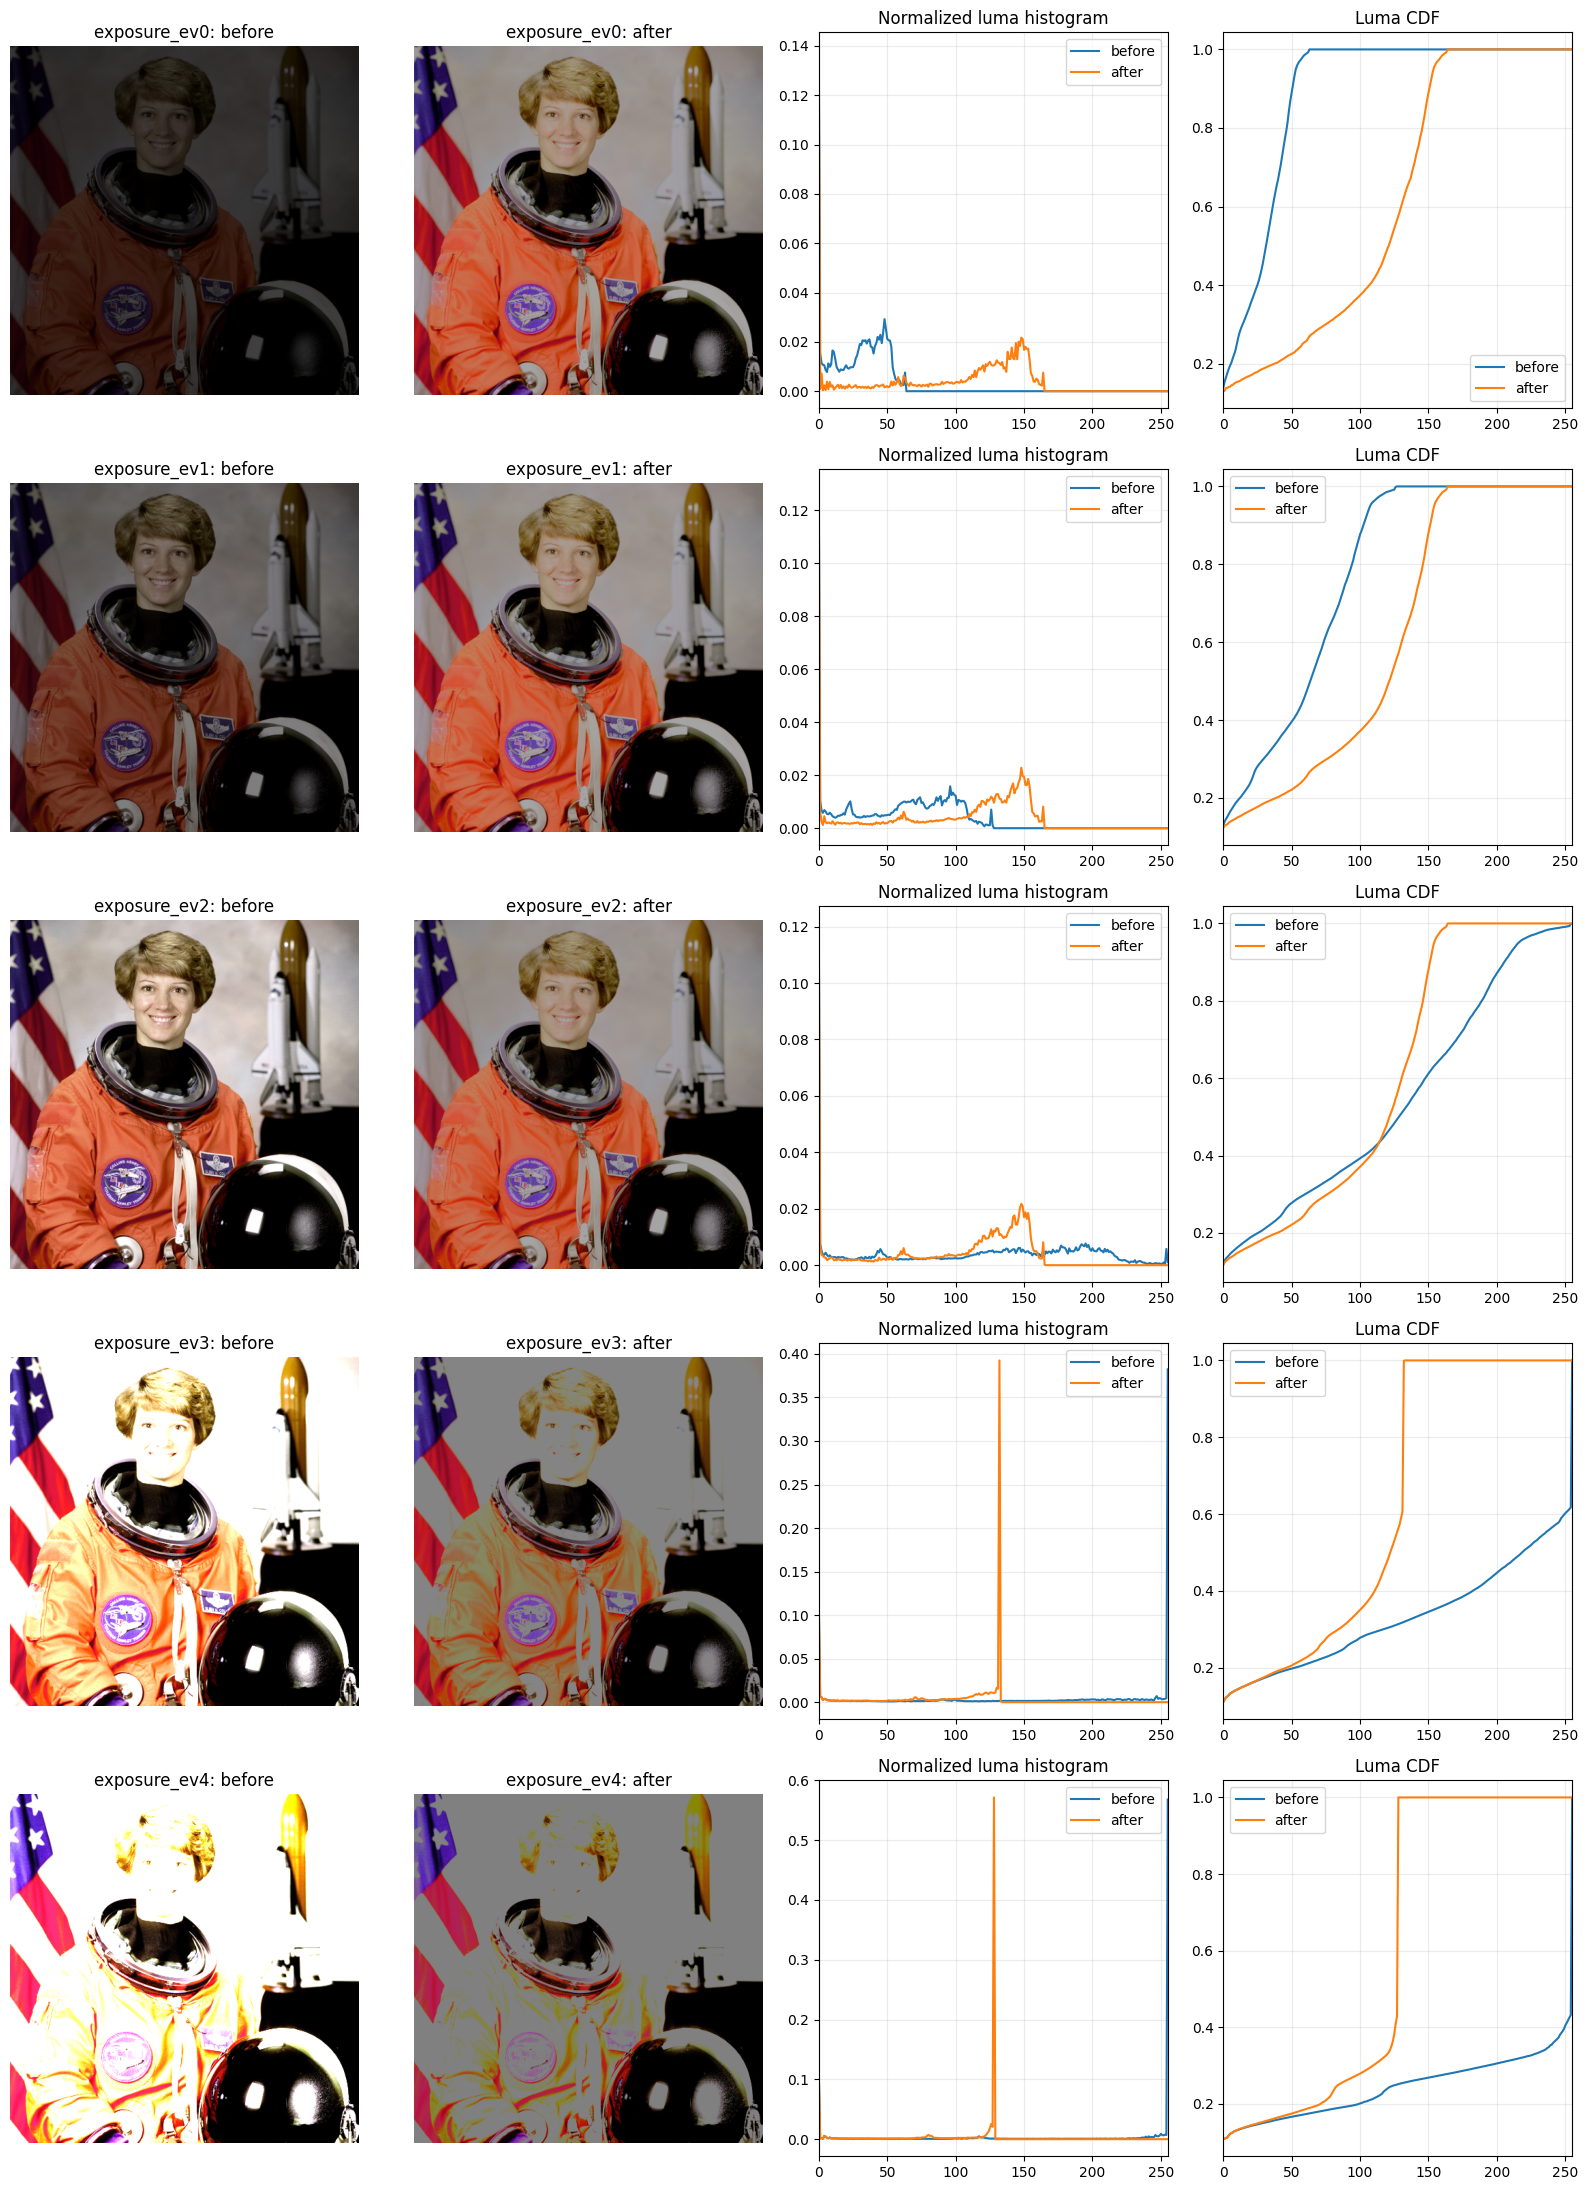

In [143]:
# 4.4 Automatic correction and pairwise W1 analysis.
exposure_names = [f"exposure_ev{index}" for index in range(5)]
exposure_images = [images[name] for name in exposure_names]
corrected_exposures = [auto_correct(image) for image in exposure_images]

exposure_luma = [to_luma(image) for image in exposure_images]
corrected_luma = [to_luma(image) for image in corrected_exposures]

pairwise_rows = []
for first in range(5):
    for second in range(first + 1, 5):
        before = wasserstein1(
            hist(exposure_luma[first]),
            hist(exposure_luma[second]),
        )
        after = wasserstein1(
            hist(corrected_luma[first]),
            hist(corrected_luma[second]),
        )
        pairwise_rows.append((first, second, before, after))

print("4.4 pairwise normalized-luminance W1 distances:")
for first, second, before, after in pairwise_rows:
    print(f"EV{first}-EV{second}: before={before:.6f}, after={after:.6f}")

before_distances = np.array([row[2] for row in pairwise_rows])
after_distances = np.array([row[3] for row in pairwise_rows])
print(f"Before mean={before_distances.mean():.6f}, maximum={before_distances.max():.6f}")
print(f"After mean={after_distances.mean():.6f}, maximum={after_distances.max():.6f}")

print("Corrected output luminance statistics:")
for name, luma in zip(exposure_names, corrected_luma):
    percentile_range = np.percentile(luma, (1, 99))
    print(
        f"{name}: std={luma.std():.3f}, "
        f"1st-99th percentile={percentile_range[0]:.1f}-"
        f"{percentile_range[1]:.1f}"
    )

fig, axes = plt.subplots(5, 4, figsize=(16, 22))
for row, (name, original, corrected, original_y, corrected_y) in enumerate(
    zip(exposure_names, exposure_images, corrected_exposures, exposure_luma, corrected_luma)
):
    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"{name}: before")
    axes[row, 1].imshow(corrected)
    axes[row, 1].set_title(f"{name}: after")
    axes[row, 2].plot(levels, hist(original_y) / original_y.size, label="before")
    axes[row, 2].plot(levels, hist(corrected_y) / corrected_y.size, label="after")
    axes[row, 2].set_title("Normalized luma histogram")
    axes[row, 3].plot(levels, cdf(hist(original_y)), label="before")
    axes[row, 3].plot(levels, cdf(hist(corrected_y)), label="after")
    axes[row, 3].set_title("Luma CDF")

    axes[row, 2].legend()
    axes[row, 3].legend()
    for column in (0, 1):
        axes[row, column].axis("off")
    for column in (2, 3):
        axes[row, column].set_xlim(0, 255)
        axes[row, column].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()